# Ensemble Final
El siguiente notebook contiene el proceso de armado del ensemble final del modelo.


La siguiente imagen muestra la estructura del ensemble, el cual se irá explicando a medida que avanza el notebook

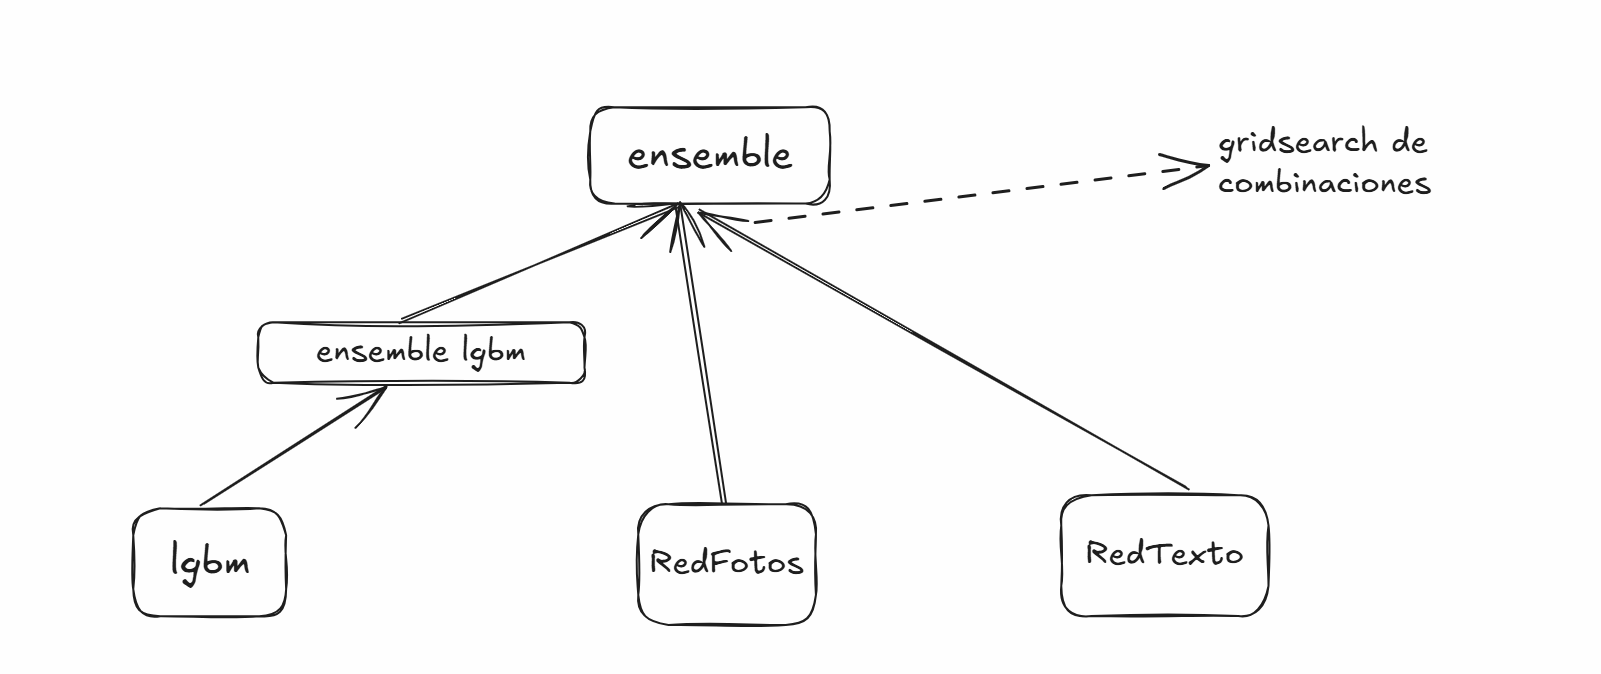

# Librerias

In [ ]:
import numpy as np 
import pandas as pd 

from sklearn.metrics import cohen_kappa_score, accuracy_score,balanced_accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold #Split y cross Validation

from plotly import express as px

from utils import plot_confusion_matrix, get_artifact_filename

import os

from json import loads

from joblib import load, dump

#Gradient Boosting
import lightgbm as lgb

import optuna
from optuna.artifacts import FileSystemArtifactStore, upload_artifact

# textblob
from textblob import TextBlob

import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable
import torch.nn.functional as F

import random


c:\Users\josek\miniconda3\envs\ldi2_cuda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Directorios

In [2]:
# Paths
BASE_DIR = '../'
PATH_TO_MODELS = os.path.join(BASE_DIR, "work/models")
PATH_TO_TRAIN = os.path.join(BASE_DIR, "input/petfinder-adoption-prediction/train/train_FE.csv")
PATH_TO_IMAGES_DIR = os.path.join(BASE_DIR, "input/petfinder-adoption-prediction/train_images")
PATH_TO_TEMP_FILES = os.path.join(BASE_DIR, "work/optuna_temp_artifacts")
PATH_TO_OPTUNA_ARTIFACTS = os.path.join(BASE_DIR, "work/optuna_artifacts")
SEED = 42
TEST_SIZE = 0.2 #Facción para train/test= split


# Carga de dataset y division train/test

In [3]:
dataset = pd.read_csv(PATH_TO_TRAIN)

In [4]:
#Separo un 20% para test estratificado opr target
train, test = train_test_split(dataset,
                               test_size = TEST_SIZE,
                               random_state = SEED,
                               stratify = dataset.AdoptionSpeed)

# LGBM

En primera instancia entrenamos un modelo de LGBM de datos estructurados. El mismo es obtenido en el notebook **01_Tabulares.ipynb**.

Una vez obtenidos los mejores hyperparámetros, se realiza un ensemble de múltiples modelos similares, con la diferencia en la semilla de entrenamiento del LBGM. Luego, se promedian scores para obtener un score final.

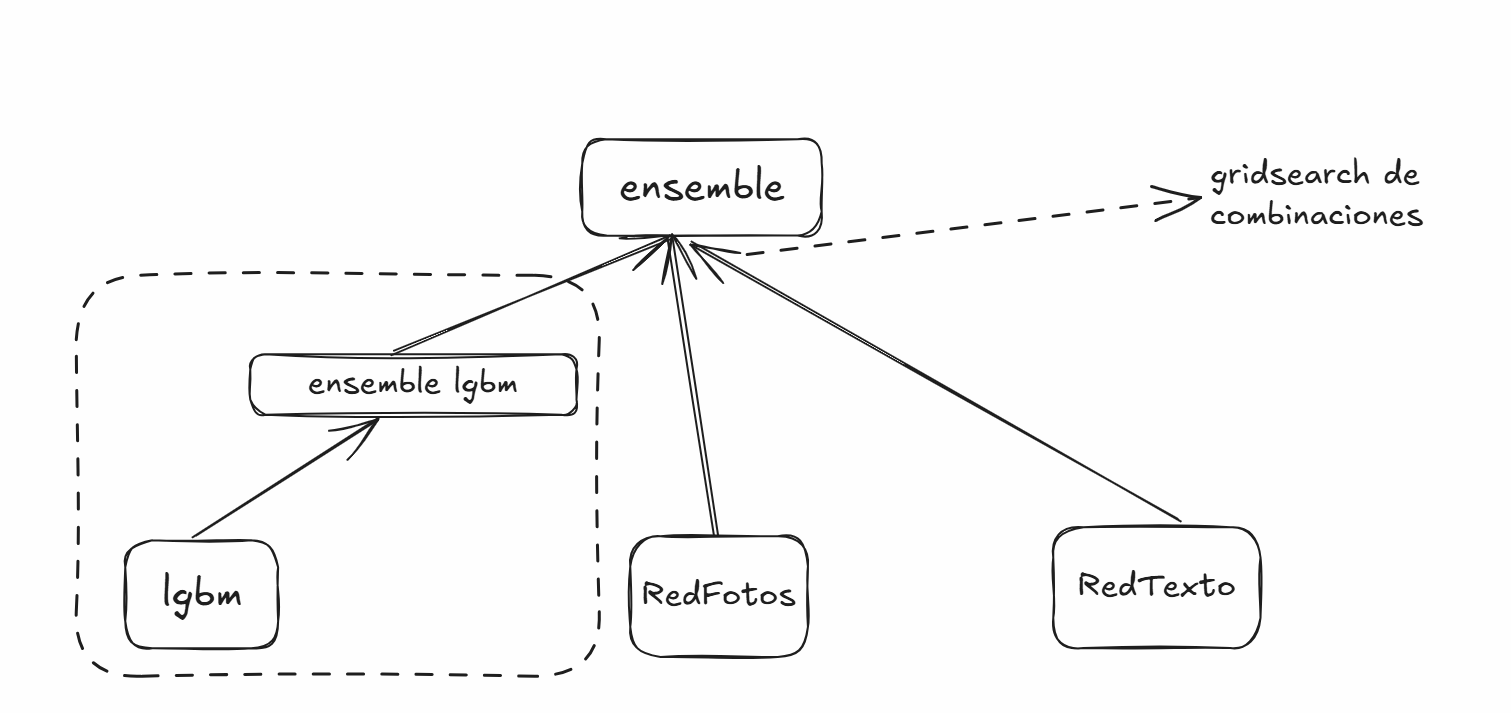

Cargo el modelo obtenido

In [5]:
study_lgb = optuna.create_study(direction='maximize',
                            storage="sqlite:///../work/db.sqlite3",  # Specify the storage URL here.
                            study_name="04 - LGB Multiclass CV - FE12",
                            load_if_exists = True)

[I 2025-08-28 23:27:24,167] Using an existing study with name '04 - LGB Multiclass CV - FE12' instead of creating a new one.


In [6]:
#Defino features a usar en el modelo (los mismos que en el estudio)
features = ['Type',
 'Age',
 'Breed1',
 'Breed2',
 'Gender',
 'Color1',
 'Color2',
 'Color3',
 'MaturitySize',
 'FurLength',
 'Vaccinated',
 'Dewormed',
 'Sterilized',
 'Health',
 'Quantity',
 'Fee',
 'State',
 'VideoAmt',
 'PhotoAmt',
 'HasName',
 'DescLen',
 'score_salud',
 'Puro',
 'AgeRange',
 'Color_comb',
 'Content',
 'logFee',
 'polarity',
 'Subjectivity',
 'state_gdp',
 'state_population',
 'gdp_vs_population'
 ]

label = 'AdoptionSpeed'

In [7]:
#Genero dataframes de train y test con sus respectivos targets
X_train = train[features]
y_train = train[label]

X_test = test[features]
y_test = test[label]

In [8]:
# Se cargan los hiperparámetross obtenidos
final_params = {
    **study_lgb.best_params,  # hiperparámetros de Optuna
    'objective': 'multiclass',
    'num_class': len(y_train.unique()),
    'verbosity': -1,
    'num_threads': 10
}

In [9]:
# Se crea un dataset para trabajar en LGBM
lgb_dataset = lgb.Dataset(data=X_train,
                            label=y_train,
                            free_raw_data=False)

Ensemble:

In [ ]:
random.seed(SEED) # Defino una semilla inicial para poder hacer el experimento reproducible
n = 300  # Numero de semillas a usar en el ensemble
seed_list = random.sample(range(1, 10000), n) # Se generan n semillas aleatoriamente entre 1 y 10000

scores_ensemble = np.zeros((len(y_test),len(y_train.unique()))) # Se genera una matriz de resultados con 0s inicialmente

n = 0 # Se reescribe n para utilizar para checkear por donde va el codigo
for seed in seed_list:
    n += 1
    if n%10 == 0 : # Este if es totalmente eliminable y no cambia nada en el código, es más es un agregado de performance innecesario, pero nos da info de cómo va
        print(f"Vamos por la iteracion {n}")
        
    final_params['seed'] = seed
    
    #Entreno el modelo
    lgb_model = lgb.train(final_params,
                            lgb_dataset,
                            num_boost_round = 100
                            )
    scores_ensemble = scores_ensemble + lgb_model.predict(X_test)

scores_ensemble = scores_ensemble/n  #lo dividimos por n solo para no darle un peso extra al hacer el ensemble final. Si se usara solo esto, sería indistinto

Vamos por la iteracion 10
Vamos por la iteracion 20
Vamos por la iteracion 30
Vamos por la iteracion 40
Vamos por la iteracion 50
Vamos por la iteracion 60
Vamos por la iteracion 70
Vamos por la iteracion 80
Vamos por la iteracion 90
Vamos por la iteracion 100
Vamos por la iteracion 110
Vamos por la iteracion 120
Vamos por la iteracion 130
Vamos por la iteracion 140
Vamos por la iteracion 150
Vamos por la iteracion 160
Vamos por la iteracion 170
Vamos por la iteracion 180
Vamos por la iteracion 190
Vamos por la iteracion 200
Vamos por la iteracion 210
Vamos por la iteracion 220
Vamos por la iteracion 230
Vamos por la iteracion 240
Vamos por la iteracion 250
Vamos por la iteracion 260
Vamos por la iteracion 270
Vamos por la iteracion 280
Vamos por la iteracion 290
Vamos por la iteracion 300


In [11]:
# Creo un dataframe para manipular luego en el ensemble final

df_lgbm = pd.DataFrame({
    "PetID": test["PetID"].values,
    "AdoptionSpeed": test["AdoptionSpeed"].values,
    "pred": [list(x) for x in scores_ensemble]  # cada fila sigue siendo una lista
})

In [12]:
# Se checkea el Kappa
cohen_kappa_score(y_test, scores_ensemble.argmax(axis=1),weights = 'quadratic')

0.3343115335383442

# Red Fotos
Seguidamente, entrenamos una red neuronal para predecir la velocidad de adopción en base a las fotos de los animales, entrenamiente que se encuentra en **02_Resnet50.ipynb**.

Una vez entrenado el modelo, se importa y se predicen los resultados de test

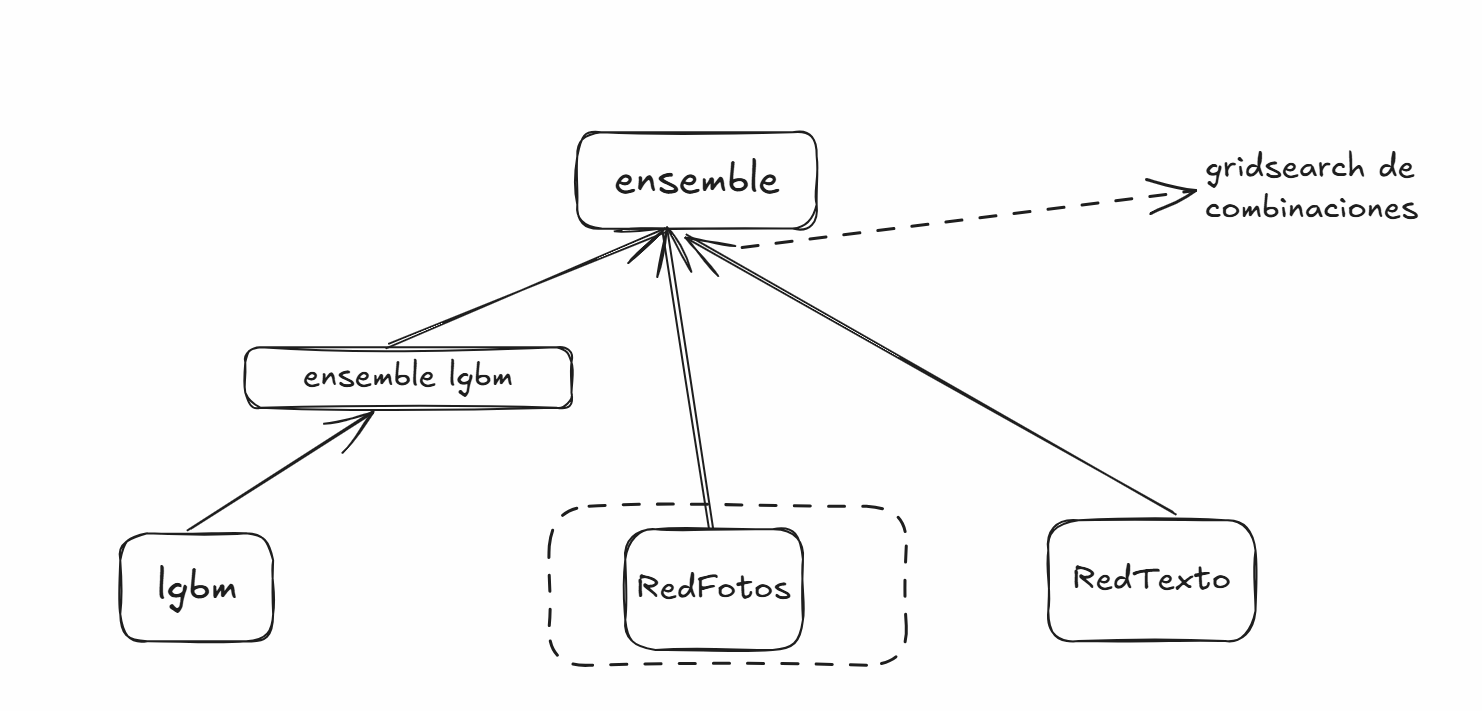

In [ ]:
# Cargamos modelo ya entrenado

MODEL_NAME = '04 ResNet'

MODEL_VERSION = '1.0.1'

study_resnet = optuna.create_study(direction='maximize',
                            storage="sqlite:///../work/db.sqlite3",  # Specify the storage URL here.
                            study_name=f'{MODEL_NAME}_{MODEL_VERSION}',
                            load_if_exists = True)

# comento porque no funciona
# resnet_dataset = load(os.path.join(PATH_TO_OPTUNA_ARTIFACTS,get_artifact_filename(study_resnet,'test')))

[I 2025-08-26 22:06:22,990] Using an existing study with name '04 ResNet_1.0.1' instead of creating a new one.


Por alguna razon no trae el df el database, así que hago la predicción nuevamente

In [ ]:
# Se carga el modelo

path_modelo = os.path.join(PATH_TO_TEMP_FILES, "04 ResNet_1.0.1_1.pth")
model = torch.load(path_modelo)


C:\Users\josek\AppData\Local\Temp\ipykernel_7608\1248213604.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(path_modelo)


In [ ]:
# Se cargan imagenes (ya preparadas en el notebook mencionado)

from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# mismas transformaciones que usaste para train/val
transform = transforms.Compose([
    transforms.Resize((299,299)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # valores de ImageNet
                         [0.229, 0.224, 0.225])
])

new_val_directory = os.path.join(BASE_DIR, 'work/val_images_classes')
# Dataset de test
test_dataset = datasets.ImageFolder(new_val_directory, transform=transform)

# DataLoader
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers = 8)



In [ ]:
# Se obtienen los ids
test_sample_ids = [os.path.basename(path).split('-')[0] for path, _ in test_loader.dataset.samples]


In [ ]:
# Se realiza la predicción
import torch
import torch.nn.functional as F
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

all_preds = []
all_labels = []
all_probabilities = []

with torch.no_grad():  
    for images, labels in test_loader: 
        images, labels = images.to(device), labels.to(device) 
        outputs = model(images)  # forward pass (these are the logits)
        
        # Apply softmax to get probabilities
        probabilities = F.softmax(outputs, dim=1)
        
        # Get the predicted class (the one with the highest probability)
        _, preds = torch.max(probabilities, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

In [ ]:
# Se obtiene el dataset resultante para usar en el ensemble
df_preds = pd.DataFrame({
    "PetID": test_sample_ids,
    "prediction": all_preds,
    "probs": all_probabilities   # esto queda como lista, podés expandirlo en columnas
})

In [ ]:
# Se guarda en el mismo origen (se podría mejorar)
df_preds.to_csv("resnet_pred.csv", index= False)

In [23]:
# En caso de querer saltearse el paso final se puede cargar el mismo df en una proxima corrida
def str_to_array(s):
    return np.fromstring(s.strip("[]"), sep=" ")

df_preds = pd.read_csv("resnet_pred.csv", converters={"probs": str_to_array})

# Red Texto
Como tercer paso, entrenamos una red neuronal que busca predecir la velocidad de adoción en base la descripción de la mascota. El mismo es obtenido en el notebook **03_text_classification_optuna.ipynb**.

En este paso se importa directamente el resultado obtenido en el notebook recientemente mencionado.

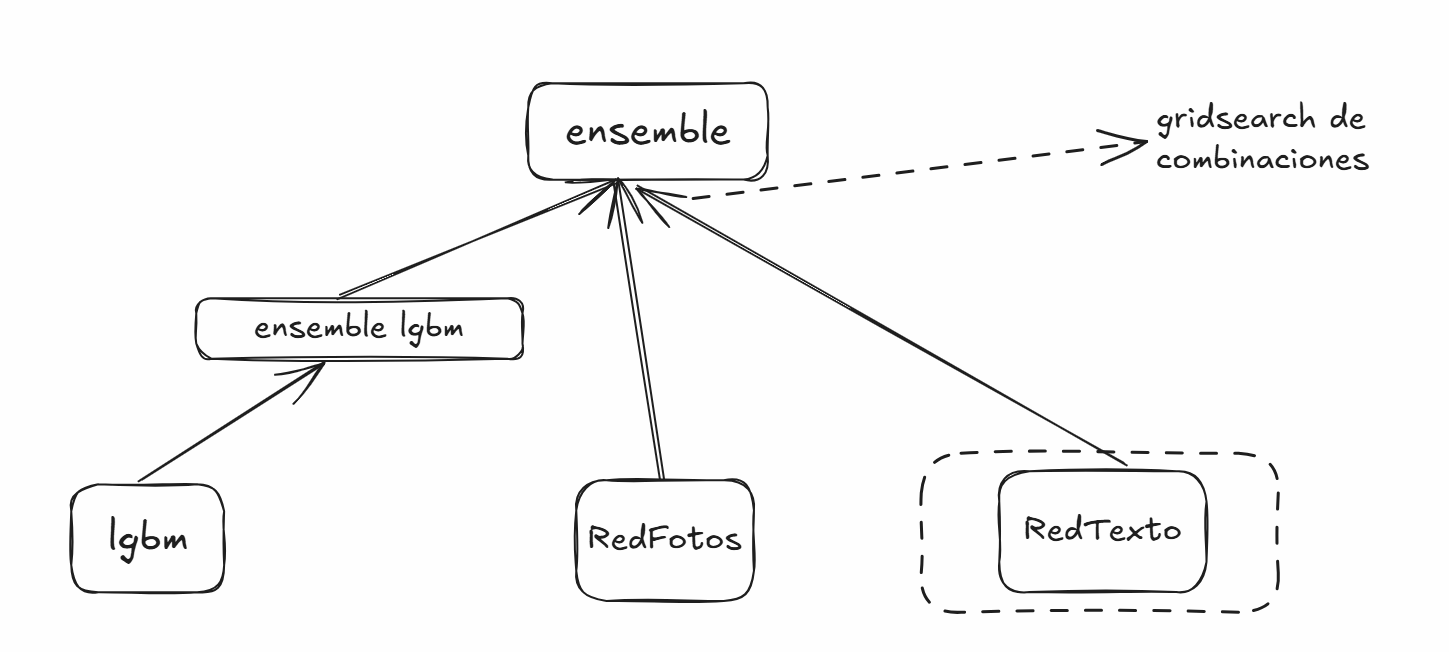

In [14]:
# Se carga el estudio y el dataset
MODEL_NAME = '06 Bert'

MODEL_VERSION = '1.1'

study_bert = optuna.create_study(direction='maximize',
                            storage="sqlite:///../work/db.sqlite3",  # Specify the storage URL here.
                            study_name=f'{MODEL_NAME}_{MODEL_VERSION}',
                            load_if_exists = True)

bert_dataset = load(os.path.join(PATH_TO_OPTUNA_ARTIFACTS,get_artifact_filename(study_bert,'test')))

[I 2025-08-28 23:32:49,728] Using an existing study with name '06 Bert_1.1' instead of creating a new one.


In [15]:
bert_dataset

,PetID,pred,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,...,AgeRange,Color_comb,Content,logFee,polarity,Subjectivity,state_gdp,state_population,gdp_vs_population,labels
0,8e76c8e39,"[0.026189942, 0.22295089, 0.25067097, 0.215753...",2,Kali,3,264,0,2,1,2,...,1,3,1,3.912023,0.065798,0.505742,280.698,54.62141,5.138974,1
1,6436c1a59,"[0.026189942, 0.22295089, 0.25067097, 0.215753...",1,Godiva,12,307,0,2,2,7,...,2,2,1,-inf,0.427778,0.672222,280.698,54.62141,5.138974,2
2,988988d5b,"[0.026189942, 0.22295089, 0.25067097, 0.215753...",2,Cikenet,3,266,0,1,2,7,...,1,2,1,-inf,0.750000,0.800000,190.075,16.74621,11.350329,1
3,efbf1703a,"[0.026189942, 0.22295089, 0.25067097, 0.215753...",2,No Name,1,266,0,2,1,0,...,1,1,1,-inf,0.500000,0.500000,280.698,54.62141,5.138974,2
4,543130f60,"[0.026189942, 0.22295089, 0.25067097, 0.215753...",1,BoiBoi,24,307,0,1,5,7,...,3,2,1,-inf,0.120972,0.551299,280.698,54.62141,5.138974,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2991,23874f644,"[0.026189942, 0.22295089, 0.25067097, 0.215753...",1,Patch,8,307,0,2,2,7,...,2,2,1,-inf,0.400000,0.800000,280.698,54.62141,5.138974,3
2992,e7f7066b6,"[0.026189942, 0.22295089, 0.25067097, 0.215753...",1,Terry,24,179,307,1,2,3,...,3,3,0,-inf,0.700000,0.600000,280.698,54.62141,5.138974,4
2993,36e7f8d83,"[0.026189942, 0.22295089, 0.25067097, 0.215753...",2,Pets + Strays : BlueEyed BlackWhite,1,266,0,2,5,6,...,1,3,1,-inf,0.150000,0.358333,190.075,16.74621,11.350329,3
2994,4d163b731,"[0.026189942, 0.22295089, 0.25067097, 0.215753...",1,Snowy,6,195,0,2,1,7,...,2,2,1,-inf,0.000000,0.000000,190.075,16.74621,11.350329,0


#   Ensemble
En esta etapa se procede a realizar el ensemble de los 3 modelos obtenidos:
-   El ensemble de LGBM
-   La red de Fotos
-   La red de Texto

El procedimiento para ensamblarlo involucra hacer un gridsearch para determinar cuál es la mejor combinación

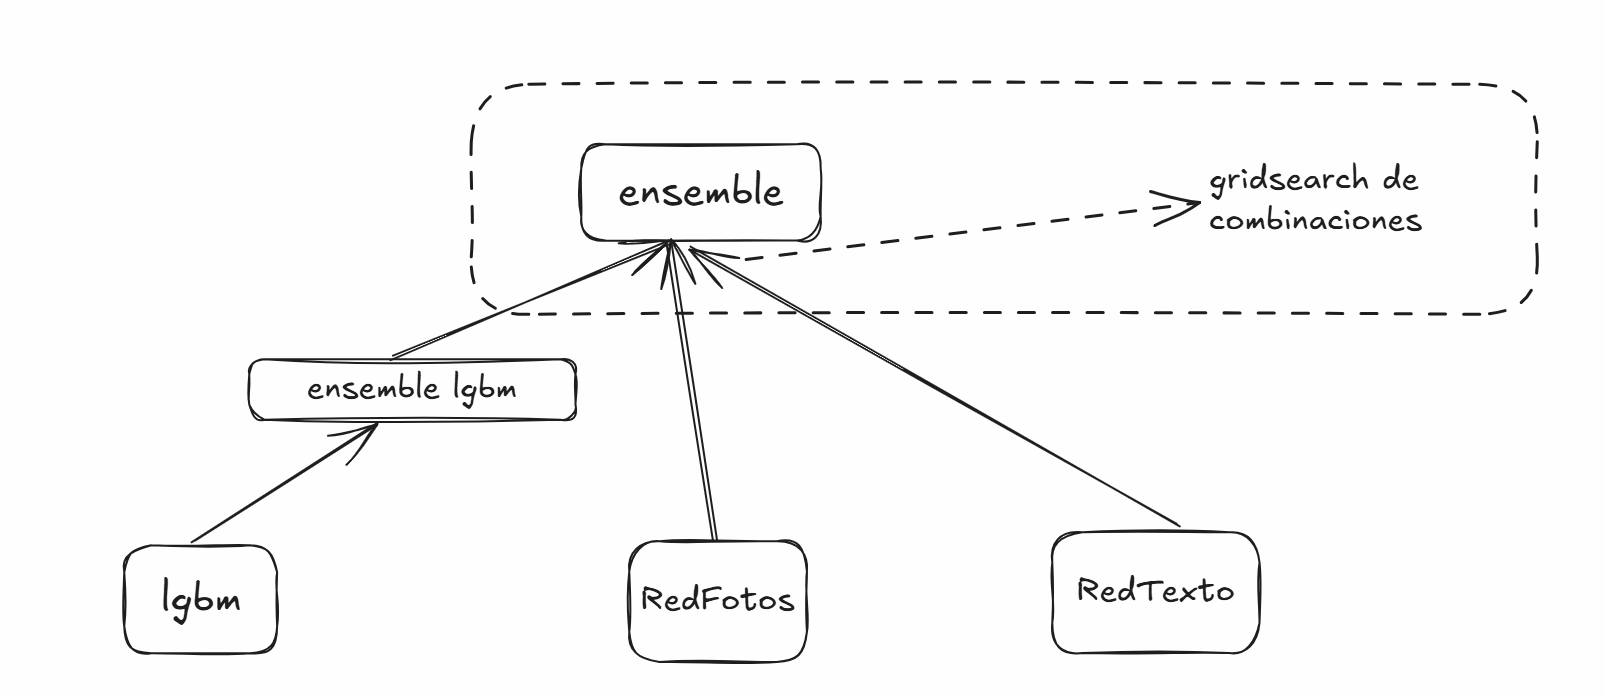

In [ ]:
#Todo mergear datasets

In [30]:
np.array(df_lgbm["pred"][0])

array([0.00541025, 0.14560229, 0.51635616, 0.25025878, 0.08237252])

In [35]:
merged_datasets = df_lgbm[['PetID', 'pred', 'AdoptionSpeed']].rename({'pred':'lgb_pred_score'},axis=1).merge(df_preds[['PetID', 'probs']].rename({'probs':'resnet_pred_score'},axis=1),
                  on='PetID', how='outer').merge(bert_dataset[['PetID', 'pred']].rename({'pred':'bert_pred_score'},axis=1),
                  on='PetID', how='outer')

merged_datasets['resnet_pred_score'] = [np.zeros(5) if type(i) is float else  i for i in merged_datasets['resnet_pred_score'] ]
merged_datasets['bert_pred_score'] = [np.zeros(5) if type(i) is float else  i for i in merged_datasets['bert_pred_score'] ]

In [ ]:
# Merge inicial para checkear que todo ande bien
merged_datasets['blend_pred_score'] = [r['lgb_pred_score']+r['bert_pred_score']+r['resnet_pred_score'] for i,r in merged_datasets.iterrows()]

merged_datasets['blended_pred'] = [r.argmax() for r in merged_datasets['blend_pred_score']]

In [37]:
merged_datasets

,PetID,lgb_pred_score,AdoptionSpeed,resnet_pred_score,bert_pred_score,blend_pred_score,blended_pred
0,002230dea,"[0.015049875709668563, 0.2270385008294194, 0.4...",1,"[0.065365, 0.2593714, 0.30193618, 0.17815673, ...","[0.026189942, 0.22295089, 0.25067097, 0.215753...","[0.10660481762255805, 0.7093607914897053, 1.03...",2
1,0063f83c9,"[0.01922842213008956, 0.19088059983978412, 0.2...",1,"[0.04438516, 0.25963533, 0.267516, 0.22689702,...","[0.026189942, 0.22295089, 0.25067097, 0.215753...","[0.08980352404297903, 0.67346682050007, 0.8164...",4
2,0073c33d0,"[0.0024817565562152383, 0.22390601997739992, 0...",3,"[0.02137689, 0.2616293, 0.41771343, 0.23647287...","[0.026189942, 0.22295089, 0.25067097, 0.215753...","[0.05004858846910472, 0.7084862106376859, 1.00...",2
3,00bfa5da9,"[0.00738559331468644, 0.09262726262092348, 0.3...",4,"[0.01118642, 0.05716666, 0.17154244, 0.1796687...","[0.026189942, 0.22295089, 0.25067097, 0.215753...","[0.04476195522757592, 0.3727448132812094, 0.79...",4
4,00c19f4fa,"[0.006287871831515086, 0.12291575190976146, 0....",2,"[0.01475629, 0.10579637, 0.2878427, 0.30633965...","[0.026189942, 0.22295089, 0.25067097, 0.215753...","[0.047234103744404565, 0.4516630125700474, 1.0...",2
...,...,...,...,...,...,...,...
2994,ffa5c6c35,"[0.032298028458142426, 0.36658000676415925, 0....",4,"[0.02703902, 0.18730569, 0.2133231, 0.1566089,...","[0.026189942, 0.22295089, 0.25067097, 0.215753...","[0.08552699037103191, 0.7768365874244452, 0.57...",4
2995,ffd697903,"[0.010182528935864663, 0.24868105688126335, 0....",3,"[0.02196689, 0.12732834, 0.2517128, 0.25089166...","[0.026189942, 0.22295089, 0.25067097, 0.215753...","[0.05833936084875414, 0.5989602875415493, 0.94...",2
2996,ffe0f06ab,"[0.0029372269493269446, 0.30437007638599073, 0...",2,"[0.02329137, 0.21686247, 0.31418595, 0.2879794...","[0.026189942, 0.22295089, 0.25067097, 0.215753...","[0.052418538862216424, 0.7441834370462767, 0.9...",2
2997,ffe5a0271,"[0.0036318256484852364, 0.49936853930768726, 0...",3,"[0.05803073, 0.15998475, 0.28288728, 0.2257171...","[0.026189942, 0.22295089, 0.25067097, 0.215753...","[0.08785249756137473, 0.8823041799679732, 0.78...",1


In [40]:
#gridsearch basico 11x11x11*

#inicializo lista de valores a probar
vals = list(range(0,11,1))

# Convertir columnas a arrays 2D: filas x clases
lgb_preds = np.vstack(merged_datasets['lgb_pred_score'].apply(np.array).values)
bert_preds = np.vstack(merged_datasets['bert_pred_score'].apply(np.array).values)
resnet_preds = np.vstack(merged_datasets['resnet_pred_score'].apply(np.array).values)

score = -9999
prop_vals = [-1,-1,-1]

for v1 in vals:
    for v2 in vals:
        for v3 in vals:
            if v1 + v2 + v3 == 0:
                continue
            # blending ponderado
            blend = v1*lgb_preds + v2*bert_preds + v3*resnet_preds
            blended_pred = np.argmax(blend, axis=1)
            
            iter_score = cohen_kappa_score(merged_datasets['AdoptionSpeed'], blended_pred, weights='quadratic')
            
            if iter_score > score:
                score = iter_score
                prop_vals = [v1, v2, v3]

print(f"El mejor score fue {score} con pesos {prop_vals}")
            



El mejor score fue 0.3786395382851315 con pesos [5, 0, 9]


El mejor resultado del gridsearch (con todas las salvedades que debería tener) nos da de hacer 5 veces el lgbm sumado a 9 veces la red de descripción. Sin considerar las fotos.

Para tener una comparativa, vemos cómo da teniendo solo la suma de los 3.

In [41]:
# Merge inicial
merged_datasets['blend_pred_score'] = [r['lgb_pred_score']+r['bert_pred_score']+r['resnet_pred_score'] for i,r in merged_datasets.iterrows()]

merged_datasets['blended_pred'] = [r.argmax() for r in merged_datasets['blend_pred_score']]

In [42]:
cohen_kappa_score(merged_datasets['AdoptionSpeed'], blended_pred, weights='quadratic')

0.3723169395922774

La diferencia es apenas medio punto porcentual. Podríamos utilizar esta forma homogénea.

#   Como nos va en Kaggle?

Para evaluar cómo performa en kaggle hay que volver a entrenar a todos los modelos. Esto es, con los hiperparámetros del train/val, se realiza un nuevo entrenamiento pero ahora del dataset completo.

In [43]:
# Cargo el dataset para testear

PATH_TO_TEST = os.path.join(BASE_DIR, "input/petfinder-adoption-prediction/test/test.csv")
dataset_val = pd.read_csv(PATH_TO_TEST)

##  Feature Engineering

Volvemos a realizar el Feature Engineering en los datos de test

In [ ]:
#FE
# Feature Engineering

# link: https://medium.com/%40thom42/pet-cat-and-dog-adoption-speed-prediction-kaggle-petfindermy-part-1-eda-631f9538cde6
dataset_val['HasName'] = dataset_val['Name'].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip().lower() in ['not named', 'no name yet', 'none', 'unnamed', 'no name'] else 1
)


## len descripcion

dataset_val['DescLen'] = dataset_val['Description'].apply(
    lambda x: len(str(x))
)


## Si cumple todos los requisitos de salud

dataset_val['score_salud'] = ( 
    (dataset_val['Vaccinated'] == 1).astype(int) + 
    (dataset_val['Sterilized'] == 1).astype(int) + 
    (dataset_val['Dewormed'] == 1).astype(int) 
)

## Pureza
dataset_val["Puro"] = np.where((dataset_val["Breed2"] > 0) | (dataset_val["Breed1"] == 307), 0, 1)


## cachorro | inter | adulto

def age_range(row):
    if row.Age < 6:
        return 1
    elif row.Age < 24:
        return 2
    else:
        return 3
        
dataset_val["AgeRange"] = dataset_val.apply(age_range, axis=1)


## Cantidad de colores

def color_checker(row):
    if row.Color3 != 0:
        return 3
    else:
        if row.Color2 != 0:
            return 2
        else:
            return 1
        
dataset_val["Color_comb"] = dataset_val.apply(color_checker, axis=1)

# Tiene algo de contenido

def content_checker(row):
    cant = row.VideoAmt + row.PhotoAmt
    if cant > 0:
        return 1
    else:
        return 0
        
dataset_val["Content"] = dataset_val.apply(content_checker, axis=1)

# ln Fee
dataset_val['logFee'] = dataset_val['Fee'].apply(lambda x: np.log(x))

# Analisis de sentimiento

def getPolarity(row):
    text = str(row.Description)
    return TextBlob(text).sentiment.polarity
    
dataset_val["polarity"] = dataset_val.apply(getPolarity, axis = 1)

def getSubjectivity(row):
    text = str(row.Description)
    return TextBlob(text).sentiment.subjectivity

dataset_val["Subjectivity"] = dataset_val.apply(getSubjectivity, axis = 1)

# Estados https://www.kaggle.com/c/petfinder-adoption-prediction/discussion/78040

# state GDP: https://en.wikipedia.org/wiki/List_of_Malaysian_states_by_GDP in billions
state_gdp = {
    41336: 116.679,
    41325: 40.596,
    41367: 23.02,
    41401: 190.075,
    41415: 5.984,
    41324: 37.274,
    41332: 42.389,
    41335: 52.452,
    41330: 67.629,
    41380: 5.642,
    41327: 81.284,
    41345: 80.167,
    41342: 121.414,
    41326: 280.698,
    41361: 32.270
}

# state population: https://en.wikipedia.org/wiki/Malaysia
state_population = {
    41336: 33.48283,
    41325: 19.47651,
    41367: 15.39601,
    41401: 16.74621,
    41415: 0.86908,
    41324: 8.21110,
    41332: 10.21064,
    41335: 15.00817,
    41330: 23.52743,
    41380: 2.31541,
    41327: 15.61383,
    41345: 32.06742,
    41342: 24.71140,
    41326: 54.62141,
    41361: 10.35977
}

dataset_val["state_gdp"] = dataset_val['State'].map(state_gdp)
dataset_val["state_population"] = dataset_val['State'].map(state_population)
dataset_val["gdp_vs_population"] = dataset_val["state_gdp"] / dataset_val["state_population"]

C:\Users\josek\AppData\Local\Temp\ipykernel_28552\3130694293.py:67: RuntimeWarning: divide by zero encountered in log
  dataset_val['logFee'] = dataset_val['Fee'].apply(lambda x: np.log(x))


In [45]:
# Se vuelven a definir las mismas features de LGBM (esta casilla es reduntante si se viene corriendo desde el comienzo)
features = ['Type',
 'Age',
 'Breed1',
 'Breed2',
 'Gender',
 'Color1',
 'Color2',
 'Color3',
 'MaturitySize',
 'FurLength',
 'Vaccinated',
 'Dewormed',
 'Sterilized',
 'Health',
 'Quantity',
 'Fee',
 'State',
 'VideoAmt',
 'PhotoAmt',
 'HasName',
 'DescLen',
 'score_salud',
 'Puro',
 'AgeRange',
 'Color_comb',
 'Content',
 'logFee',
 'polarity',
 'Subjectivity',
 'state_gdp',
 'state_population',
 'gdp_vs_population'
 ]

label = 'AdoptionSpeed'

In [49]:
# Se definen el X e Y para ingestar en los entrenamientos. el dataset corresponde al dataset completo de train
X = dataset[features]
Y = dataset[label]

##  Entrenamiento Final

### LGBM

Se realiza primeramente una prueba del un solo LGBM para ver cómo da en kaggle. Luego se procede a hacer el ensemble.

In [50]:
final_params = {
    **study_lgb.best_params,  # hiperparámetros de Optuna
    'objective': 'multiclass',
    'num_class': len(Y.unique()),
    'verbosity': -1,
    'num_threads': 10
}

In [52]:
#Dataset para entrenamiento
lgb_dataset = lgb.Dataset(data=X,
                            label=Y,
                            free_raw_data=False)

In [53]:
#Entreno el modelo
lgb_model = lgb.train(final_params,
                        lgb_dataset,
                        num_boost_round = 100
                        )

In [54]:
# Defino data para predecir
X_val = dataset_val[features]

In [55]:
# Predicción
res = lgb_model.predict(X_val)

Se estructura un dataset para exportar y hacer el submit manual en Kaggle


In [59]:
# Calcular argmax de cada lista de res
preds = np.argmax(res, axis=1)

# Crear el DataFrame final
df_out = pd.DataFrame({
    "PetID": dataset_val["PetID"],
    "AdoptionSpeed": preds
})

In [62]:
df_out.to_csv("submit.csv", index = False)

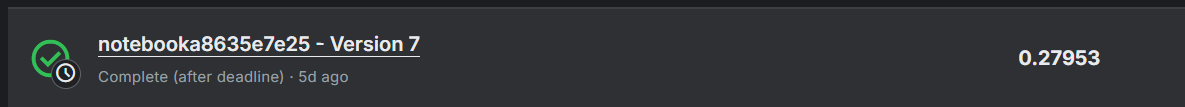

#### Ensemble LGBM

In [56]:
# Defino data para predecir
X_val = dataset_val[features]

In [ ]:
random.seed(SEED) #para hacerlo replicable
n = 300
seed_list = random.sample(range(1, 10000), n)

scores_ensemble = np.zeros((len(X_val),len(y_train.unique())))

n = 0
for seed in seed_list:
    n += 1
    if n%10 == 0 :
        print(f"Vamos por la iteracion {n}")
        
    final_params['seed'] = seed
    
    #Entreno el modelo
    lgb_model = lgb.train(final_params,
                            lgb_dataset,
                            num_boost_round = 100
                            )
    scores_ensemble = scores_ensemble + lgb_model.predict(X_val)

Vamos por la iteracion 10
Vamos por la iteracion 20
Vamos por la iteracion 30
Vamos por la iteracion 40
Vamos por la iteracion 50
Vamos por la iteracion 60
Vamos por la iteracion 70
Vamos por la iteracion 80
Vamos por la iteracion 90
Vamos por la iteracion 100
Vamos por la iteracion 110
Vamos por la iteracion 120
Vamos por la iteracion 130
Vamos por la iteracion 140
Vamos por la iteracion 150
Vamos por la iteracion 160
Vamos por la iteracion 170
Vamos por la iteracion 180
Vamos por la iteracion 190
Vamos por la iteracion 200
Vamos por la iteracion 210
Vamos por la iteracion 220
Vamos por la iteracion 230
Vamos por la iteracion 240
Vamos por la iteracion 250
Vamos por la iteracion 260
Vamos por la iteracion 270
Vamos por la iteracion 280
Vamos por la iteracion 290
Vamos por la iteracion 300


In [21]:
scores_ensemble = scores_ensemble/n

In [23]:
len(dataset_val)

3972

In [ ]:
# Calcular argmax de cada lista de res
# preds = np.argmax(scores_ensemble, axis=1)

# # Crear el DataFrame final
# df_out = pd.DataFrame({
#     "PetID": dataset_val["PetID"],
#     "AdoptionSpeed": preds
# })

In [ ]:
# df_out.to_csv("submitensemble.csv", index = False)

In [28]:
df_lgbm = pd.DataFrame({
    "PetID": dataset_val["PetID"],
    "pred": [list(x) for x in scores_ensemble]
})

In [29]:
df_lgbm

,PetID,pred
0,e2dfc2935,"[0.02732055450495899, 0.11001960583349919, 0.2..."
1,f153b465f,"[0.02261693353466008, 0.23437747256016073, 0.2..."
2,3c90f3f54,"[0.007611228187267074, 0.2758648767105807, 0.4..."
3,e02abc8a3,"[0.006754675994847637, 0.03610480019608258, 0...."
4,09f0df7d1,"[0.01096418187566303, 0.13859467774157092, 0.2..."
...,...,...
3967,ae57f8d52,"[0.002881459657967343, 0.04728922218482851, 0...."
3968,83432904d,"[0.004899877723148265, 0.0509706175938517, 0.1..."
3969,399013029,"[0.005856888428535321, 0.12319410992122544, 0...."
3970,fd80b8c80,"[0.005495092578648076, 0.04318314955726705, 0...."


### FOTOS

####   Cargo df ya procesado

In [65]:
def str_to_array(s):
    return np.fromstring(s.strip("[]"), sep=" ")

df_resnet = pd.read_csv("resnet_kaggle_pred.csv", converters={"probs": str_to_list})

In [66]:
df_resnet

,PetID,prediction,probs
0,000aa306a,4,"[0.01704191, 0.17058726, 0.10604554, 0.1301760..."
1,002089611,2,"[0.00264569, 0.00677213, 0.80962133, 0.1043164..."
2,002efc654,4,"[0.00982574, 0.03475704, 0.12145655, 0.2137736..."
3,0061e61ce,1,"[0.06857671, 0.44780016, 0.14695434, 0.1223481..."
4,0070b950a,4,"[0.02844326, 0.20794329, 0.19177645, 0.1759651..."
...,...,...,...
3853,ffb8f5704,1,"[0.08527005, 0.5598237, 0.22452457, 0.10314246..."
3854,ffbbed680,2,"[0.04636136, 0.322329, 0.3273095, 0.21982634, ..."
3855,ffc5dccdd,2,"[0.00392894, 0.29536623, 0.63588965, 0.062064,..."
3856,ffc9bd892,3,"[0.03091489, 0.20752656, 0.24313678, 0.3696779..."


### TEXTO

####   Cargo df ya procesado

### ENSEMBLE

In [75]:
merged_datasets = df_lgbm[['PetID', 'pred']].rename({'pred':'lgb_pred_score'},axis=1).merge(df_resnet[['PetID', 'probs']].rename({'probs':'resnet_pred_score'},axis=1),
                  on='PetID', how='outer')

In [82]:
merged_datasets['resnet_pred_score'] = [np.zeros(5) if pd.isna(i) is float else  i for i in merged_datasets['resnet_pred_score'] ]

In [83]:
# Merge inicial
merged_datasets['blend_pred_score'] = merged_datasets.apply(
    lambda r: np.array(r['lgb_pred_score']) + np.array(r['resnet_pred_score']),
    axis=1
)

merged_datasets['blended_pred'] = [r.argmax() for r in merged_datasets['blend_pred_score']]

In [84]:
merged_datasets

,PetID,lgb_pred_score,resnet_pred_score,blend_pred_score,blended_pred
0,000aa306a,"[0.0020081032302420527, 0.026663974815928804, ...","[0.01704191, 0.17058726, 0.10604554, 0.1301760...","[0.019050013230242052, 0.1972512348159288, 0.2...",4
1,001630d8d,"[0.005250414066933576, 0.023395714439066496, 0...","[0.0, 0.0, 0.0, 0.0, 0.0]","[0.005250414066933576, 0.023395714439066496, 0...",4
2,002089611,"[0.010447746553486887, 0.21035689717923087, 0....","[0.00264569, 0.00677213, 0.80962133, 0.1043164...","[0.013093436553486888, 0.21712902717923085, 1....",2
3,002efc654,"[0.003716501038243309, 0.058220764240671484, 0...","[0.00982574, 0.03475704, 0.12145655, 0.2137736...","[0.013542241038243308, 0.09297780424067148, 0....",4
4,0061e61ce,"[0.018350195228064067, 0.34653569980383203, 0....","[0.06857671, 0.44780016, 0.14695434, 0.1223481...","[0.08692690522806407, 0.794335859803832, 0.358...",1
...,...,...,...,...,...
3967,ffb8f5704,"[0.01046722003090789, 0.31639719048573456, 0.4...","[0.08527005, 0.5598237, 0.22452457, 0.10314246...","[0.09573727003090789, 0.8762208904857346, 0.66...",1
3968,ffbbed680,"[0.031647668139232296, 0.04977350249883992, 0....","[0.04636136, 0.322329, 0.3273095, 0.21982634, ...","[0.0780090281392323, 0.3721025024988399, 0.568...",4
3969,ffc5dccdd,"[0.004365945258350921, 0.193370681975837, 0.29...","[0.00392894, 0.29536623, 0.63588965, 0.062064,...","[0.00829488525835092, 0.488736911975837, 0.934...",2
3970,ffc9bd892,"[0.009346928114560045, 0.11183369312052584, 0....","[0.03091489, 0.20752656, 0.24313678, 0.3696779...","[0.04026181811456005, 0.31936025312052585, 0.4...",4


In [87]:
df_out = pd.DataFrame({
    "PetID": merged_datasets["PetID"],
    "AdoptionSpeed": merged_datasets["blended_pred"]
})

df_out.to_csv("submitensemble.csv", index = False)

#   Dónde podríamos investigar / mejorar ?